In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 20)

print("Librerías cargadas correctamente")
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")

Librerías cargadas correctamente
Pandas version: 3.0.2
Numpy version: 2.4.4


In [2]:
# Carga del precio Brent
# Los archivos de la EIA tienen 2 filas de cabecera que hay que saltar

brent = pd.read_csv('../data/raw/brent_daily.csv', 
                    skiprows=3,
                    names=['date', 'price_usd'], sep=';', decimal=',')

meses_es_en = {
    'ene': 'jan', 'feb': 'feb', 'mar': 'mar', 'abr': 'apr',
    'may': 'may', 'jun': 'jun', 'jul': 'jul', 'ago': 'aug',
    'sep': 'sep', 'oct': 'oct', 'nov': 'nov', 'dic': 'dec'
}

for es, en in meses_es_en.items():
    brent['date'] = brent['date'].str.replace(es, en, case=False)

# Limpieza básica
brent['date'] = pd.to_datetime(brent['date'], format='%b %d, %Y')
brent = brent.dropna()
brent = brent.sort_values('date').reset_index(drop=True)

print(f"Registros totales: {len(brent)}")
print(f"Período: {brent['date'].min().date()} a {brent['date'].max().date()}")
print(f"\nPrimeras filas:")
print(brent.head())
print(f"\nÚltimas filas:")
print(brent.tail())
print(f"\nEstadísticas básicas:")
print(brent['price_usd'].describe())

Registros totales: 9883
Período: 1987-05-20 a 2026-05-01

Primeras filas:
        date  price_usd
0 1987-05-20      18.63
1 1987-05-21      18.45
2 1987-05-22      18.55
3 1987-05-25      18.60
4 1987-05-26      18.63

Últimas filas:
           date  price_usd
9878 2026-04-27     113.89
9879 2026-04-28     117.62
9880 2026-04-29     124.16
9881 2026-04-30     124.24
9882 2026-05-01     118.26

Estadísticas básicas:
count   9883.00
mean      51.10
std       32.71
min        9.10
25%       19.54
50%       46.04
75%       74.72
max      143.95
Name: price_usd, dtype: float64


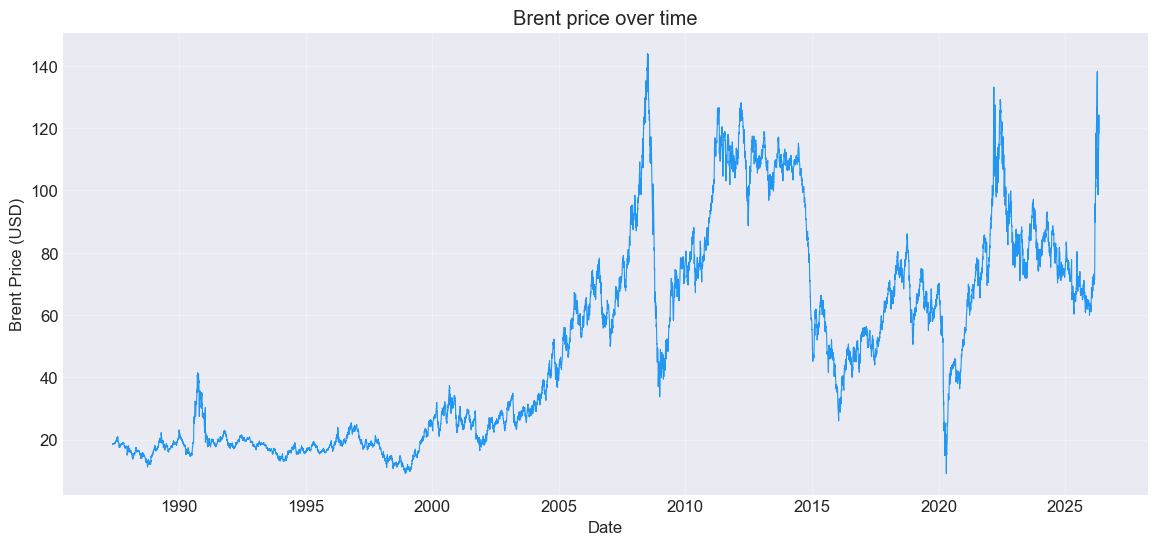

In [3]:
eje_x = brent['date']
eje_y = brent['price_usd']

plt.figure(figsize=(14, 6))
plt.plot(eje_x, eje_y, color='#2196F3', linewidth=0.8)
plt.title('Brent price over time')
plt.xlabel('Date')
plt.ylabel('Brent Price (USD)')
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
# Carga del precio WTI
# Los archivos de la EIA tienen 2 filas de cabecera que hay que saltar

wti = pd.read_csv('../data/raw/wti_daily.csv', 
                    skiprows=3,
                    names=['date', 'price_usd'], sep=';', decimal=',')

meses_es_en = {
    'ene': 'jan', 'feb': 'feb', 'mar': 'mar', 'abr': 'apr',
    'may': 'may', 'jun': 'jun', 'jul': 'jul', 'ago': 'aug',
    'sep': 'sep', 'oct': 'oct', 'nov': 'nov', 'dic': 'dec'
}

for es, en in meses_es_en.items():
    wti['date'] = wti['date'].str.replace(es, en, case=False)

# Limpieza básica
wti['date'] = pd.to_datetime(wti['date'], format='%b %d, %Y')
wti = wti.dropna()
wti = wti.sort_values('date').reset_index(drop=True)

print(f"Registros totales: {len(wti)}")
print(f"Período: {wti['date'].min().date()} a {wti['date'].max().date()}")
print(f"\nPrimeras filas:")
print(wti.head())
print(f"\nÚltimas filas:")
print(wti.tail())
print(f"\nEstadísticas básicas:")
print(wti['price_usd'].describe())

Registros totales: 10153
Período: 1986-01-02 a 2026-05-04

Primeras filas:
        date  price_usd
0 1986-01-02      25.56
1 1986-01-03      26.00
2 1986-01-06      26.53
3 1986-01-07      25.85
4 1986-01-08      25.87

Últimas filas:
            date  price_usd
10148 2026-04-28     103.45
10149 2026-04-29     110.47
10150 2026-04-30     108.64
10151 2026-05-01     105.38
10152 2026-05-04     109.76

Estadísticas básicas:
count   10153.00
mean       48.32
std        29.50
min       -36.98
25%        20.33
50%        43.04
75%        71.30
max       145.31
Name: price_usd, dtype: float64


In [5]:
merged_brent_wti = brent.merge(wti, on='date', suffixes=('_brent', '_wti'))
merged_brent_wti['spread'] = merged_brent_wti['price_usd_brent'] - merged_brent_wti['price_usd_wti']
merged_brent_wti.describe()

,date,price_usd_brent,price_usd_wti,spread
count,9708,9708.00,9708.00,9708.00
mean,2006-10-14 21:43:14.313967,51.17,49.48,1.69
min,1987-05-20 00:00:00,9.10,-36.98,-22.18
25%,1997-01-06 18:00:00,19.51,20.97,-1.61
50%,2006-10-24 12:00:00,46.04,45.75,-0.66
75%,2016-06-29 06:00:00,74.81,71.97,3.69
max,2026-05-01 00:00:00,143.95,145.31,54.34
std,NaN,32.80,29.34,5.40


In [6]:
max_date = merged_brent_wti.loc[merged_brent_wti['spread'].idxmax()]
min_date = merged_brent_wti.loc[merged_brent_wti['spread'].idxmin()]
print(min_date)

date               2008-09-22 00:00:00
price_usd_brent                 100.43
price_usd_wti                   122.61
spread                          -22.18
Name: 5330, dtype: object


In [7]:
merged_brent_wti.nlargest(10, 'spread')

,date,price_usd_brent,price_usd_wti,spread
8226,2020-04-20,17.36,-36.98,54.34
6085,2011-09-23,109.17,79.58,29.59
6071,2011-09-02,115.92,86.45,29.47
6074,2011-09-08,117.99,89.05,28.94
6084,2011-09-22,109.21,80.29,28.92
6083,2011-09-21,114.26,85.77,28.49
6099,2011-10-13,112.45,83.96,28.49
6080,2011-09-16,116.26,87.96,28.30
6073,2011-09-07,117.50,89.34,28.16
6086,2011-09-26,107.90,79.97,27.93


In [8]:
merged_brent_wti.nsmallest(10, 'spread')

,date,price_usd_brent,price_usd_wti,spread
5330,2008-09-22,100.43,122.61,-22.18
5327,2008-09-17,86.09,97.39,-11.30
5333,2008-09-25,100.45,111.54,-11.09
5329,2008-09-19,93.46,104.05,-10.59
5400,2008-12-31,35.82,44.60,-8.78
5342,2008-10-08,80.77,88.94,-8.17
5359,2008-10-31,60.00,68.10,-8.10
4371,2004-11-15,39.32,46.95,-7.63
5361,2008-11-04,62.78,70.41,-7.63
5347,2008-10-15,66.86,74.38,-7.52


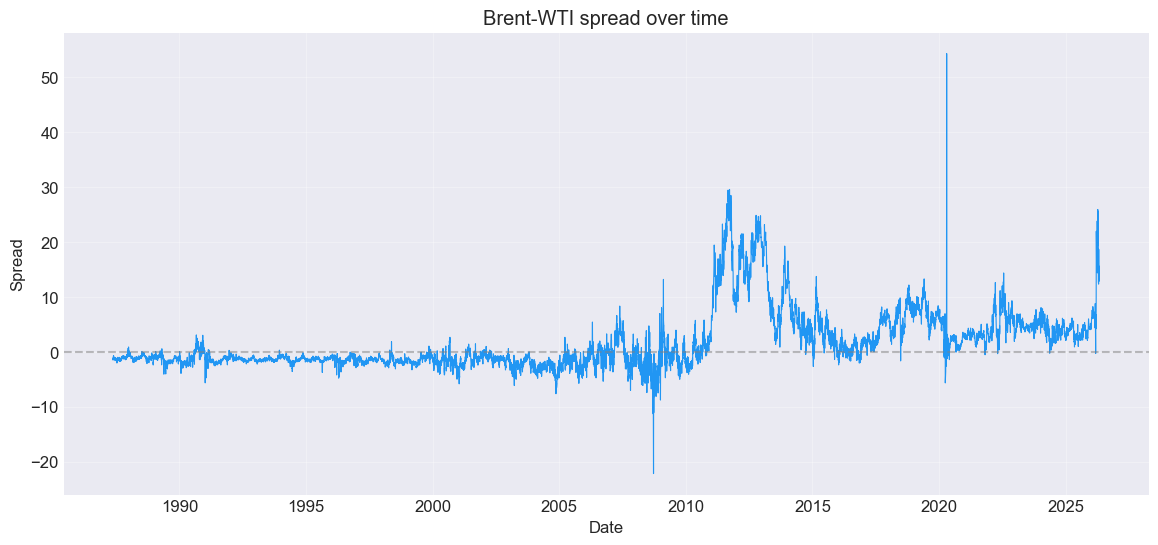

In [9]:
plt.figure(figsize=(14, 6))
plt.plot(merged_brent_wti['date'], merged_brent_wti['spread'], color='#2196F3', linewidth=0.8)
plt.title('Brent-WTI spread over time')
plt.xlabel('Date')
plt.ylabel('Spread')
plt.grid(True, alpha=0.3)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.show()

In [10]:
eia_month = pd.read_csv('../data/raw/INT-Export-06-02-2026_12-44-43.csv',skiprows=1)
eia_month = eia_month.drop(0)
eia_month = eia_month.drop('API',axis=1)
eia_month = eia_month.rename(columns={'Unnamed: 1':'country'})
eia_month.head()

eia_month_long = eia_month.melt(id_vars='country',var_name='date_str', value_name='production_kbd')
eia_month_long['date_str'] = pd.to_datetime(eia_month_long['date_str'], format='%b %Y')
eia_month_long['production_kbd'] = pd.to_numeric(eia_month_long['production_kbd'], errors='coerce')

eia_dates = eia_month_long.groupby('country')['date_str'].min()
eia_dates.head(20)

country
Brazil                 1973-01-01
Canada                 1973-01-01
China                  1973-01-01
Iran                   1973-01-01
Iraq                   1973-01-01
Kuwait                 1973-01-01
Mexico                 1973-01-01
Russia                 1973-01-01
Saudi Arabia           1973-01-01
United Arab Emirates   1973-01-01
United States          1973-01-01
Venezuela              1973-01-01
Name: date_str, dtype: datetime64[us]

In [11]:
non_nan = eia_month_long[eia_month_long['production_kbd'].notna()]
grouped_non_nan = non_nan.groupby('country')['date_str'].min()
grouped_non_nan.head(20)

country
Brazil                 1984-01-01
Canada                 1973-01-01
China                  1973-01-01
Iran                   1973-01-01
Iraq                   1973-01-01
Kuwait                 1973-01-01
Mexico                 1973-01-01
Russia                 1992-01-01
Saudi Arabia           1973-01-01
United Arab Emirates   1973-01-01
United States          1973-01-01
Venezuela              1973-01-01
Name: date_str, dtype: datetime64[us]

La producción de Rusia empieza en 1992 tras la disolución de la URSS.

Pasamos a unir el spread de Brent y WTI con la procucción, pero para ello debemos tener el mismo formato temporal

In [12]:
merged_brent_wti_month = merged_brent_wti.resample('ME',on='date').mean()

In [13]:
merged_brent_wti_month.head()

,price_usd_brent,price_usd_wti,spread
date,,,
1987-05-31,18.58,19.54,-0.96
1987-06-30,18.86,20.07,-1.21
1987-07-31,19.86,21.34,-1.49
1987-08-31,18.98,20.31,-1.33
1987-09-30,18.31,19.53,-1.22


Como el spread tiene como fecha el último día del mes y la producción el primero, creamos en ambos frames una columna Period

In [14]:
merged_brent_wti_month['period']=merged_brent_wti_month.index.to_period('M')
merged_brent_wti_month.head()

,price_usd_brent,price_usd_wti,spread,period
date,,,,
1987-05-31,18.58,19.54,-0.96,1987-05
1987-06-30,18.86,20.07,-1.21,1987-06
1987-07-31,19.86,21.34,-1.49,1987-07
1987-08-31,18.98,20.31,-1.33,1987-08
1987-09-30,18.31,19.53,-1.22,1987-09


In [15]:
production = eia_month_long
production['period'] = production['date_str'].dt.to_period('M')
production.head(20)

,country,date_str,production_kbd,period
0,Brazil,1973-01-01,NaN,1973-01
1,Canada,1973-01-01,1778.00,1973-01
2,China,1973-01-01,1012.00,1973-01
3,Iran,1973-01-01,5808.00,1973-01
4,Iraq,1973-01-01,1527.00,1973-01
5,Kuwait,1973-01-01,3768.00,1973-01
6,Mexico,1973-01-01,453.00,1973-01
7,Russia,1973-01-01,NaN,1973-01
8,Saudi Arabia,1973-01-01,6876.00,1973-01
9,United Arab Emirates,1973-01-01,1416.00,1973-01


In [16]:
production['country'] = production['country'].str.strip()
production_usa = production[production['country'] == 'United States']
production_usa.head()
merged_spread_prod = merged_brent_wti_month.merge(production_usa, on='period')
merged_spread_prod.head(20)

,price_usd_brent,price_usd_wti,spread,period,country,date_str,production_kbd
0,18.58,19.54,-0.96,1987-05,United States,1987-05-01,8336.00
1,18.86,20.07,-1.21,1987-06,United States,1987-06-01,8279.00
2,19.86,21.34,-1.49,1987-07,United States,1987-07-01,8251.00
3,18.98,20.31,-1.33,1987-08,United States,1987-08-01,8210.00
4,18.31,19.53,-1.22,1987-09,United States,1987-09-01,8205.00
5,18.76,19.86,-1.10,1987-10,United States,1987-10-01,8364.00
6,17.78,18.85,-1.07,1987-11,United States,1987-11-01,8397.00
7,17.05,17.27,-0.22,1987-12,United States,1987-12-01,8318.00
8,16.75,17.13,-0.38,1988-01,United States,1988-01-01,8250.00
9,15.73,16.80,-1.07,1988-02,United States,1988-02-01,8374.00


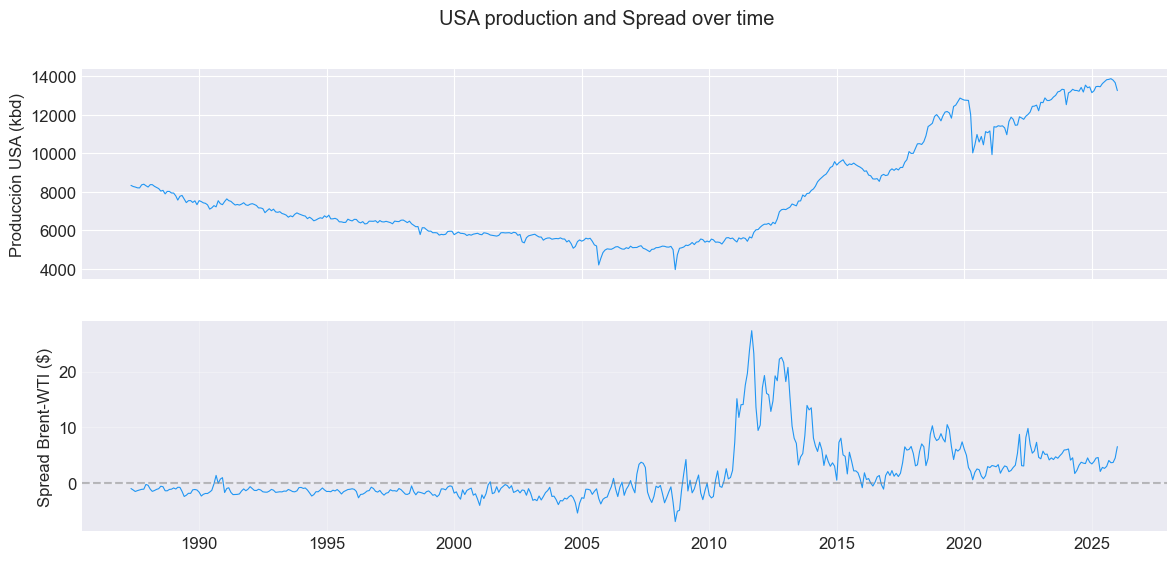

In [17]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(14, 6))
ax1.plot(merged_spread_prod['date_str'], merged_spread_prod['production_kbd'], color='#2196F3', linewidth=0.8)
ax2.plot(merged_spread_prod['date_str'], merged_spread_prod['spread'], color='#2196F3', linewidth=0.8)
ax1.set_ylabel('Producción USA (kbd)')
ax2.set_ylabel('Spread Brent-WTI ($)')
plt.grid(True, alpha=0.3)
ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)
fig.suptitle('USA production and Spread over time')
plt.show()

El cambio de régimen del spread Brent-WTI a partir de 2011 coincide temporalmente con el despegue de la producción de crudo de EEUU (de ~5.000 a ~13.000 kbd vía shale). El mecanismo: el exceso de crudo americano, atrapado por la prohibición de exportación vigente hasta 2015 y la capacidad logística limitada de Cushing, deprimió el WTI frente al Brent. La moderación parcial del spread desde 2016 es consistente con el levantamiento de dicha prohibición. La producción de EEUU es, por tanto, una variable explicativa de primer orden del spread.

Ahora cargamos los datos semanales de Cushing, lo que nos peritirá entender el efecto Shale de 2011 en adelante. Inventarios comerciales de Cushing, excluyendo la Reserva Estratégica (SPR), por ser estos los relevantes para la formación del precio del WTI.

In [18]:
cushing_weekly = pd.read_csv('../data/raw/Weekly_Cushing_OK_Ending_Stocks_excluding_SPR_of_Crude_Oil.csv', skiprows=4)
cushing_weekly = cushing_weekly.rename(columns={'Week of':'date', 'Weekly Cushing OK Ending Stocks excluding SPR of Crude Oil  Thousand Barrels':'cushing_stocks_kb'})
cushing_weekly['date'] = pd.to_datetime(cushing_weekly['date'])
cushing_monthly = cushing_weekly.resample('ME', on='date').mean().reset_index()
cushing_monthly.head()

,date,cushing_stocks_kb
0,2004-04-30,12456.25
1,2004-05-31,14834.50
2,2004-06-30,14383.50
3,2004-07-31,15884.00
4,2004-08-31,14472.25


In [19]:
cushing_monthly['period'] = cushing_monthly['date'].dt.to_period('M')
merged_cushing_spread = cushing_monthly.merge(merged_brent_wti_month, on='period')

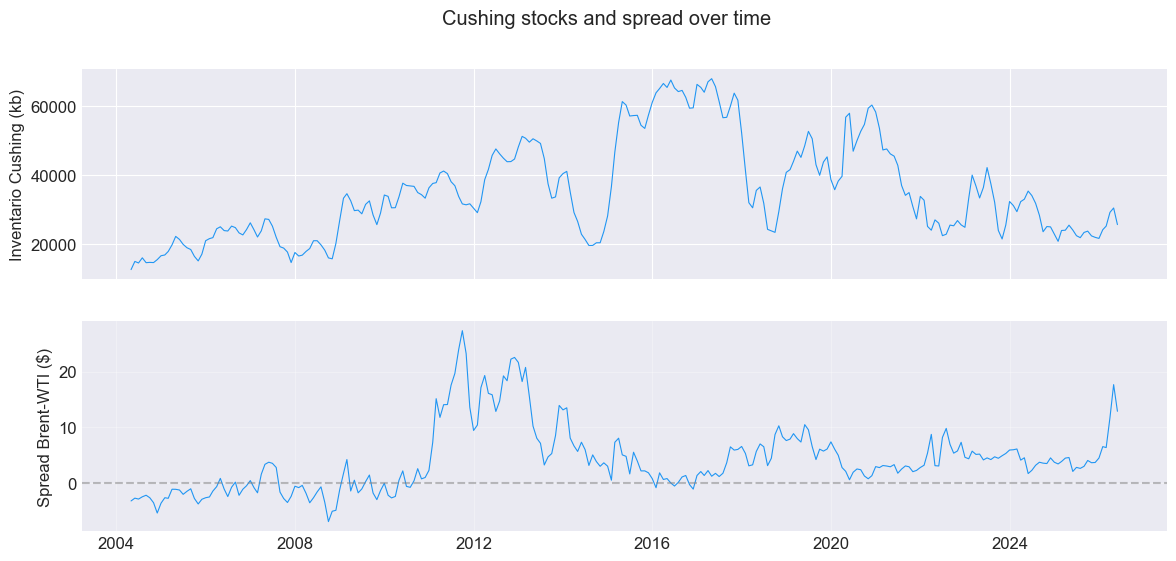

In [20]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(14, 6))
ax1.plot(merged_cushing_spread['date'], merged_cushing_spread['cushing_stocks_kb'], color='#2196F3', linewidth=0.8)
ax2.plot(merged_cushing_spread['date'], merged_cushing_spread['spread'], color='#2196F3', linewidth=0.8)
ax1.set_ylabel('Inventario Cushing (kb)')
ax2.set_ylabel('Spread Brent-WTI ($)')
plt.grid(True, alpha=0.3)
ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)
fig.suptitle('Cushing stocks and spread over time')
plt.show()

La relación entre inventarios de Cushing y spread Brent-WTI no es estacionaria. Es fuerte en 2011-2014 (Cushing saturado deprime el WTI con el spread en máximos), pero se desacopla a partir de 2016: niveles récord de inventario en Cushing coexisten con spreads moderados. La causa probable es el levantamiento de la prohibición de exportación de crudo de EEUU (dic. 2015), que convirtió Cushing de cuello de botella sin salida en un nodo con válvula de escape hacia los puertos de exportación. Implicación para el modelado: la relación inventario-spread depende del régimen institucional y no puede modelarse como homogénea en toda la serie.

In [21]:
import sys
sys.path.append('..')
from src.data.loaders import load_prices, load_production, load_cushing
prices = load_prices()
production = load_production()
cushing = load_cushing()

In [22]:
import sqlite3

conn = sqlite3.connect('../data/oganalytics.db')
print(conn.execute("SELECT name FROM sqlite_master WHERE type='table'").fetchall())
conn.close()

[('prices',), ('production',), ('inventories',)]
